In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

# Análise Exploratória dos Resultados de Segmentação dos Óstios
Este notebook realiza uma análise exploratória dos resultados da segmentação dos óstios a partir do pipeline. São apresentados gráficos e estatísticas para avaliar a qualidade das segmentações.

## Carregamento dos Dados
Os dados de saída do pipeline são carregados a partir do arquivo CSV gerado, contendo as informações de status e coordenadas dos óstios para cada imagem.

In [2]:
base_path = "../output/segmentation/8.final_results"
path_mid_res = f"{base_path}/mid_res"
path_high_res = f"{base_path}/high_res"
path_high_val_res = f"{path_high_res}/2026-03-23_14-24-53/ostios_train_summary.csv"
path_mid_val_res = f"{path_mid_res}/2026-03-05_15-35-52/ostios_train_summary.csv"

df = pd.read_csv(path_mid_val_res)
df.head()

,IMG_ID,dice_artery,artery_voxels,both_correct,both_tolerable,left_intersects,right_intersects,left_dist_mm,right_dist_mm,ostia_left,ostia_right,error,status,downscale_method,opencv_interpolation,downscale_factors,max_threshold_percentile
0,867,NaN,NaN,False,False,False,False,13.620368,1.815066,"(117, 151, 177)","(111, 129, 213)",NaN,nenhum correto,scipy,NaN,"(2, 2, 1)",99.7
1,450,NaN,NaN,False,False,False,False,62.035157,59.634382,"(46, 120, 269)","(51, 86, 258)",NaN,nenhum correto,scipy,NaN,"(2, 2, 1)",99.7
2,788,0.681813,55193.0,False,True,False,False,0.900456,0.636719,"(86, 176, 214)","(118, 153, 247)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7
3,362,0.637358,27368.0,False,True,False,False,0.773438,1.202668,"(101, 165, 185)","(116, 128, 222)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7
4,10,0.650422,33971.0,False,True,False,True,0.994369,0.000000,"(91, 161, 178)","(118, 126, 211)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7


## Distribuição dos Status de Segmentação
Visualização da quantidade de imagens para cada status de segmentação dos óstios.

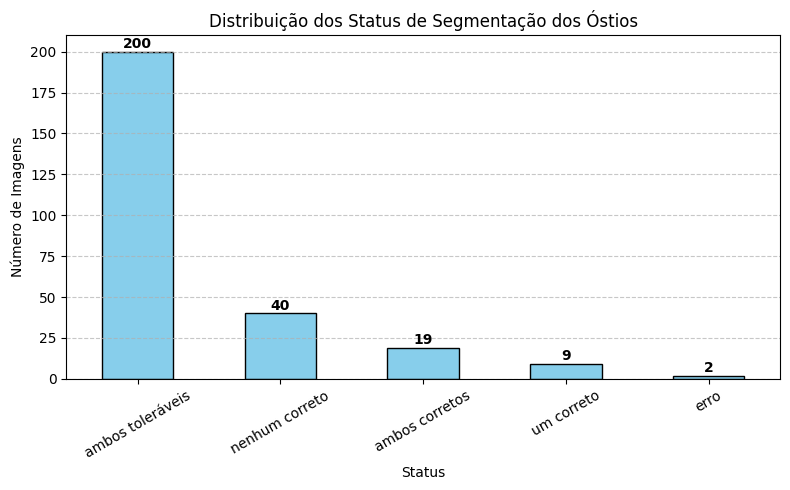

In [3]:

status_counts = df['status'].value_counts()

plt.figure(figsize=(8, 5))
ax = status_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribuição dos Status de Segmentação dos Óstios')
plt.xlabel('Status')
plt.ylabel('Número de Imagens')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

for i, v in enumerate(status_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.show()

## Acertos e Erros na Segmentação
Aqui calculamos e visualizamos a proporção de acertos (ambos toleráveis ou ambos corretos) e erros nas segmentações dos óstios.

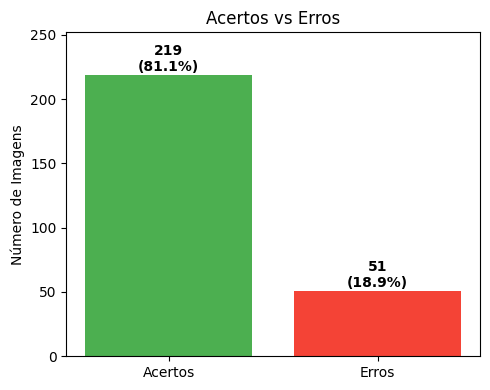

In [4]:
total = len(df)
successful_count = df['status'].isin(['ambos toleráveis', 'ambos corretos']).sum()
error_count = total - successful_count

success_percentage = 100 * successful_count / total if total > 0 else 0
error_percentage = 100 * error_count / total if total > 0 else 0

# Gráfico de barras
plt.figure(figsize=(5, 4))
plt.bar(['Acertos', 'Erros'], [successful_count, error_count], color=['#4CAF50', '#F44336'])
plt.ylabel('Número de Imagens')
plt.title('Acertos vs Erros')
for i, v in enumerate([successful_count, error_count]):
    plt.text(i, v + 0.5, f'{v}\n({[success_percentage, error_percentage][i]:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(successful_count, error_count) * 1.15)
plt.tight_layout()
plt.show()

## Análise das Distâncias entre Óstios por Status
A seguir, analisamos a distância euclidiana entre os óstios segmentados, separando por status, para investigar possíveis diferenças entre os grupos.

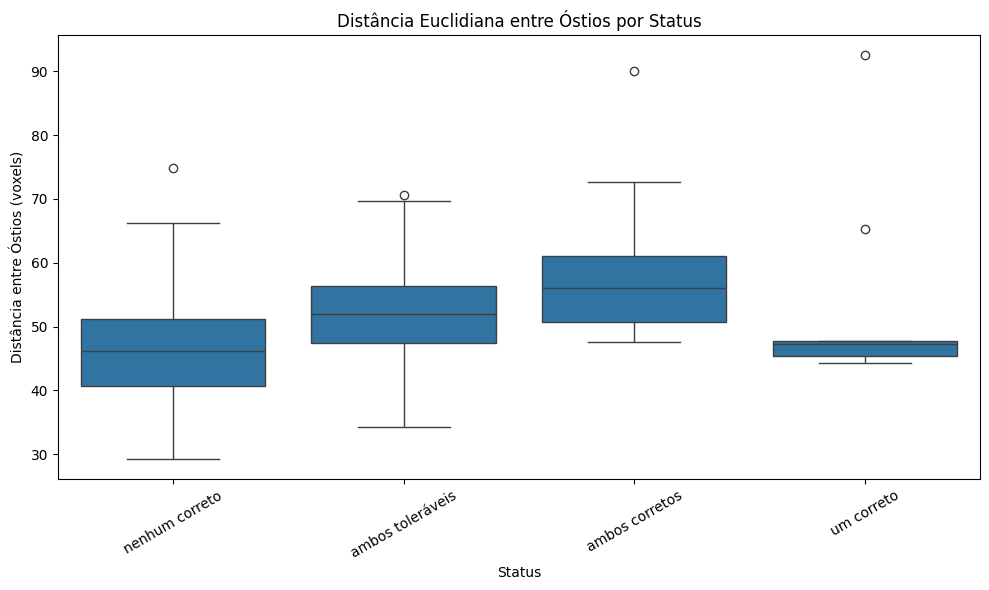

In [5]:
def safe_eval_tuple(x):
    try:
        if isinstance(x, float) and math.isnan(x):
            return np.array([np.nan, np.nan, np.nan])
        return np.array(eval(str(x), {"nan": np.nan}), dtype=float)
    except Exception:
        return np.array([np.nan, np.nan, np.nan])

ostia_left_arr = df['ostia_left'].apply(safe_eval_tuple)
ostia_right_arr = df['ostia_right'].apply(safe_eval_tuple)
df['dist_ostios'] = [np.linalg.norm(l - r) for l, r in zip(ostia_left_arr, ostia_right_arr)]

df_no_error = df[(df['status'] != 'erro') & (~df['dist_ostios'].isna()) & (df['dist_ostios'] < 1e6)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='dist_ostios', data=df_no_error)
plt.title('Distância Euclidiana entre Óstios por Status')
plt.xlabel('Status')
plt.ylabel('Distância entre Óstios (voxels)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Média das Distâncias entre Óstios por Status
Tabela com a média das distâncias entre os óstios para cada status de segmentação.

In [6]:
df_grouped = df_no_error.groupby('status', as_index=False)['dist_ostios'].mean()
df_grouped

,status,dist_ostios
0,ambos corretos,58.062615
1,ambos toleráveis,51.871250
2,nenhum correto,47.628623
3,um correto,53.425443


## Distribuição das Distâncias Left e Right (mm)
Nesta seção, comparamos as distribuições de `left_dist_mm` e `right_dist_mm` em gráficos separados.

A linha tracejada vermelha em **7 mm** representa o limite de tolerância adotado para considerar a detecção do óstio como aceitável.

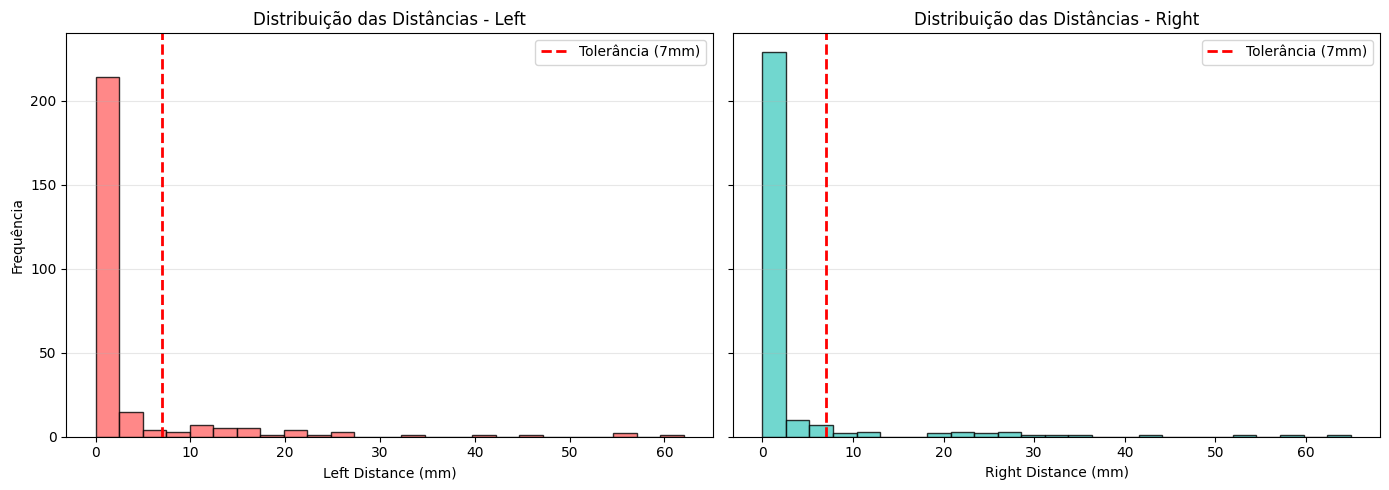

In [7]:
# Análise das distâncias left_dist_mm e right_dist_mm (distribuições)
# Preparar dados (remover NaN)
left_dist = df['left_dist_mm'].dropna()
right_dist = df['right_dist_mm'].dropna()

# Criar figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Distribuição Left
axes[0].hist(left_dist, bins=25, alpha=0.8, color='#FF6B6B', edgecolor='black')
axes[0].axvline(7.0, color='red', linestyle='--', linewidth=2, label='Tolerância (7mm)')
axes[0].set_xlabel('Left Distance (mm)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição das Distâncias - Left')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Distribuição Right
axes[1].hist(right_dist, bins=25, alpha=0.8, color='#4ECDC4', edgecolor='black')
axes[1].axvline(7.0, color='red', linestyle='--', linewidth=2, label='Tolerância (7mm)')
axes[1].set_xlabel('Right Distance (mm)')
axes[1].set_title('Distribuição das Distâncias - Right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Estatísticas das distâncias left_dist_mm e right_dist_mm
print("\n" + "="*50)
print("ESTATÍSTICAS DAS DISTÂNCIAS")
print("="*50)
print(f"\nLeft Distance (Óstio Esquerdo):")
print(f"  Média: {left_dist.mean():.3f} mm")
print(f"  Mediana: {left_dist.median():.3f} mm")
print(f"  Std Dev: {left_dist.std():.3f} mm")
print(f"  Min: {left_dist.min():.3f} mm")
print(f"  Max: {left_dist.max():.3f} mm")
print(f"  ✅ Toleráveis (≤7mm): {(left_dist <= 7.0).sum()} ({(left_dist <= 7.0).sum()/len(left_dist)*100:.1f}%)")
print(f"  ❌ Incorretos (>7mm): {(left_dist > 7.0).sum()} ({(left_dist > 7.0).sum()/len(left_dist)*100:.1f}%)")

print(f"\nRight Distance (Óstio Direito):")
print(f"  Média: {right_dist.mean():.3f} mm")
print(f"  Mediana: {right_dist.median():.3f} mm")
print(f"  Std Dev: {right_dist.std():.3f} mm")
print(f"  Min: {right_dist.min():.3f} mm")
print(f"  Max: {right_dist.max():.3f} mm")
print(f"  ✅ Toleráveis (≤7mm): {(right_dist <= 7.0).sum()} ({(right_dist <= 7.0).sum()/len(right_dist)*100:.1f}%)")
print(f"  ❌ Incorretos (>7mm): {(right_dist > 7.0).sum()} ({(right_dist > 7.0).sum()/len(right_dist)*100:.1f}%)")
print("="*50)


ESTATÍSTICAS DAS DISTÂNCIAS

Left Distance (Óstio Esquerdo):
  Média: 3.579 mm
  Mediana: 0.839 mm
  Std Dev: 8.674 mm
  Min: 0.000 mm
  Max: 62.035 mm
  ✅ Toleráveis (≤7mm): 233 (86.9%)
  ❌ Incorretos (>7mm): 35 (13.1%)

Right Distance (Óstio Direito):
  Média: 3.354 mm
  Mediana: 1.030 mm
  Std Dev: 8.606 mm
  Min: 0.000 mm
  Max: 64.930 mm
  ✅ Toleráveis (≤7mm): 244 (91.0%)
  ❌ Incorretos (>7mm): 24 (9.0%)


## Dice Score

In [9]:
# Dice score médio (ignora NaN)
if "dice_artery" in df.columns:
    df_no_zero = df[df["dice_artery"] != 0]

    dice_values = df_no_zero["dice_artery"].dropna()
    dice_mean = float(dice_values.mean()) if not dice_values.empty else 0.0
    print(f"Dice score médio: {dice_mean:.6f}")
else:
    print("Coluna 'dice_artery' não encontrada no CSV.")

Dice score médio: 0.628352


## Distribuição do Dice Score

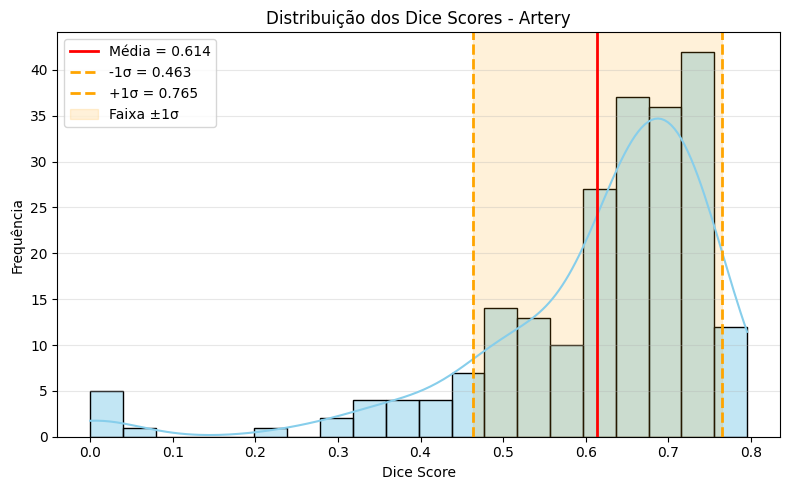

In [10]:
dice_scores = df['dice_artery'].dropna()

mu = dice_scores.mean()
sigma = dice_scores.std()

plt.figure(figsize=(8, 5))
sns.histplot(dice_scores, bins=20, kde=True, color='skyblue', edgecolor='black')

# média
plt.axvline(mu, color='red', linestyle='-', linewidth=2, label=f'Média = {mu:.3f}')

# +- 1 desvio padrão
plt.axvline(mu - sigma, color='orange', linestyle='--', linewidth=2, label=f'-1σ = {mu - sigma:.3f}')
plt.axvline(mu + sigma, color='orange', linestyle='--', linewidth=2, label=f'+1σ = {mu + sigma:.3f}')

# faixa entre mu-sigma e mu+sigma (opcional)
plt.axvspan(mu - sigma, mu + sigma, color='orange', alpha=0.15, label='Faixa ±1σ')

plt.title('Distribuição dos Dice Scores - Artery')
plt.xlabel('Dice Score')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()